# Proyecto 7 - Explorando factores de comportamiento en NovaRetail+

NovaRetail+ es una plataforma de comercio electrónico en Latinoamérica con millones de usuarios.

Para el cierre de 2024, el equipo de **Crecimiento y retención** tiene como objetivo responder:

**¿Qué factores del comportamiento del cliente están más fuertemente asociados con el ingreso anual generado?**

> Este proyecto es un análisis **correlacional** (exploratorio).  
> **Correlación ≠ causalidad.**

## Sección 1 - Cargar y explorar el dataset

En esta sección validamos:
- que el dataset cargue correctamente
- tipos de datos
- valores faltantes / rangos generales

Antes de correlacionar, primero entendemos el “terreno”.

In [62]:
# Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [63]:
# Funciones
from scipy.stats import pearsonr, spearmanr, pointbiserialr, chi2_contingency

# función para Pearson
def correlacion_pearson(df, col1, col2):
    
    coef, p_value = pearsonr(df[col1], df[col2])

    print(f'\nPearson: {col1} vs {col2}')
    print(f'Coeficiente: {coef:.4f}')
    print(f'P-value: {p_value:.4f}')


# función para Spearman
def correlacion_spearman(df, col1, col2):
    
    coef, p_value = spearmanr(df[col1], df[col2])

    print(f'\nSpearman: {col1} vs {col2}')
    print(f'Coeficiente: {coef:.4f}')
    print(f'P-value: {p_value:.4f}')

# función para correlación punto-biserial
def correlacion_punto_biserial(df, variable_binaria, variable_numerica):

    coef, p_value = pointbiserialr(
        df[variable_binaria],
        df[variable_numerica]
    )

    print(f'\nPunto-Biserial: {variable_binaria} vs {variable_numerica}')
    print(f'Coeficiente: {coef:.4f}')
    print(f'P-value: {p_value:.4f}')

# función para calcular V de Cramér
def cramers_v(df, col1, col2):

    tabla = pd.crosstab(df[col1], df[col2])

    chi2 = chi2_contingency(tabla)[0]
    n = tabla.sum().sum()

    min_dim = min(tabla.shape) - 1

    v = np.sqrt(chi2 / (n * min_dim))

    print(f'\nV de Cramér: {col1} vs {col2}')
    print(f'Coeficiente: {v:.4f}')

### Cargar Dataset

In [64]:
# Cargar el dataset y explorar datos
df = pd.read_csv('/datasets/novaretail_comportamiento_clientes_2024.csv')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   id_cliente                 15000 non-null  object 
 1   edad                       15000 non-null  float64
 2   nivel_ingreso              15000 non-null  float64
 3   visitas_mes                15000 non-null  int64  
 4   compras_mes                15000 non-null  int64  
 5   gasto_publicidad_dirigida  15000 non-null  float64
 6   satisfaccion               15000 non-null  float64
 7   miembro_premium            15000 non-null  int64  
 8   abandono                   15000 non-null  int64  
 9   tipo_dispositivo           15000 non-null  object 
 10  region                     15000 non-null  object 
 11  ingreso_anual              15000 non-null  float64
dtypes: float64(5), int64(4), object(3)
memory usage: 1.4+ MB


#### Descripción del conjunto de datos

El dataset contiene las siguientes columnas:

- `id_cliente` — Identificador único del cliente.
- `edad` — Edad del cliente.
- `nivel_ingreso` — Ingreso anual estimado del cliente.
- `visitas_mes` — Número de visitas a la aplicación o sitio web durante el mes.
- `compras_mes` — Número de compras realizadas en el mes.
- `gasto_publicidad_dirigida` — Gasto en anuncios asignado al usuario.
- `satisfaccion` — Calificación de satisfacción del cliente en una escala del 1 al 5.
- `miembro_premium` — Indica si el cliente tiene suscripción premium (1) o no (0).
- `abandono` — Indica si el cliente abandonó la plataforma (1) o no (0).
- `tipo_dispositivo` — Tipo de dispositivo utilizado por el cliente (móvil, escritorio o tablet).
- `region` — Región geográfica del cliente (norte, sur, oeste o este).
- `ingreso_anual` — Ingreso anual generado por el cliente para la empresa.

La métrica principal de análisis es `ingreso_anual`, utilizada para evaluar el impacto económico de los clientes.


In [65]:
# mostrar las primeras 5 filas
df.head(5)

,id_cliente,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,miembro_premium,abandono,tipo_dispositivo,region,ingreso_anual
0,CL-100000,44.0,28565.77,9,1,31.36,3.9,0,0,móvil,norte,23.22
1,CL-100001,36.0,29673.44,11,3,24.66,3.7,0,0,tablet,sur,93.47
2,CL-100002,46.0,30642.95,9,0,0.00,2.9,0,0,móvil,este,0.00
3,CL-100003,56.0,39468.61,8,0,6.81,3.1,0,0,móvil,este,0.00
4,CL-100004,35.0,22527.83,9,2,26.49,2.3,0,0,móvil,sur,33.76


## Sección 2 - Preparar datos y documentar supuestos

### Exploración y Limpieza

#### Exploración inicial de los datos
El conjunto de datos contiene **15,000 registros** y **12 columnas**, sin valores nulos.

**Variables numéricas**  
Se identifican las siguientes columnas numéricas:
- `edad`
- `nivel_ingreso`
- `visitas_mes`
- `compras_mes`
- `gasto_publicidad_dirigida`
- `satisfaccion`
- `ingreso_anual`

Los datos están bien categorizados.


**Variables binarias**  
Las siguientes columnas representan variables binarias:
- `miembro_premium`
- `abandono`

Ambas están codificadas como 0 y 1, **no requieren transformación adicional**.

**Variables categóricas**  
Se identifican las siguientes columnas categóricas:
- `id_cliente`
- `tipo_dispositivo`
- `region`

Estas variables están correctamente definidas y no requieren transformación adicional.

In [66]:
# Corregir el tipo de dato
# binarias
df['miembro_premium'] = df['miembro_premium'].astype('category')
df['abandono'] = df['abandono'].astype('category')

# categóricas
df['tipo_dispositivo'] = df['tipo_dispositivo'].astype('category')
df['region'] = df['region'].astype('category')

# edad entera
df['edad'] = df['edad'].astype(int)

In [67]:
# verificar cambios
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype   
---  ------                     --------------  -----   
 0   id_cliente                 15000 non-null  object  
 1   edad                       15000 non-null  int64   
 2   nivel_ingreso              15000 non-null  float64 
 3   visitas_mes                15000 non-null  int64   
 4   compras_mes                15000 non-null  int64   
 5   gasto_publicidad_dirigida  15000 non-null  float64 
 6   satisfaccion               15000 non-null  float64 
 7   miembro_premium            15000 non-null  category
 8   abandono                   15000 non-null  category
 9   tipo_dispositivo           15000 non-null  category
 10  region                     15000 non-null  category
 11  ingreso_anual              15000 non-null  float64 
dtypes: category(4), float64(4), int64(3), object(1)
memory usage: 996.8+ KB


#### Explorar variables numéricas

In [68]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,edad,nivel_ingreso,visitas_mes,compras_mes,gasto_publicidad_dirigida,satisfaccion,ingreso_anual
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,38.262400,30019.704782,10.029000,1.206467,20.149301,3.603693,36.594180
std,11.492378,9833.166305,3.158189,1.105284,10.880724,0.685300,34.484888
min,18.000000,8000.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,30.000000,23127.097500,8.000000,0.000000,12.310000,3.100000,0.000000
50%,38.000000,30023.745000,10.000000,1.000000,19.730000,3.600000,30.705000
75%,46.000000,36768.440000,12.000000,2.000000,27.292500,4.100000,58.220000
max,75.000000,74790.840000,25.000000,8.000000,75.510000,5.000000,244.690000


Diagnóstico inicial de variables numéricas

- `edad`  
Variable cuantitativa discreta.  
Los clientes tienen entre 18 y 75 años, con una media de 38.26 años y una dispersión moderada (`std = 11.49`). No se observan valores imposibles. La mediana (38) es muy cercana a la media, lo que sugiere una distribución relativamente simétrica.

- `nivel_ingreso`  
Variable cuantitativa continua.  
Presenta ingresos entre 8,000 y 74,790.84, con promedio cercano a 30,019.70. La media y mediana son casi iguales, indicando poca asimetría. La desviación estándar (`9833.17`) muestra variabilidad considerable entre clientes.

- `visitas_mes`  
Variable cuantitativa discreta.  
Los usuarios realizan entre 1 y 25 visitas mensuales, con promedio de 10 visitas. La distribución parece relativamente estable ya que la media y mediana coinciden aproximadamente.

- `compras_mes`  
Variable cuantitativa discreta.  
La mayoría de clientes realiza pocas compras al mes. El promedio es 1.21 y el 25% de los usuarios no realiza compras (`Q1 = 0`). Existe ligera asimetría positiva debido a algunos clientes con hasta 8 compras mensuales.

- `gasto_publicidad_dirigida`  
Variable cuantitativa continua.  
El gasto oscila entre 0 y 75.51. La media es 20.15 y la mediana 19.73, lo que indica una distribución relativamente balanceada. Existen clientes sin inversión publicitaria.

- `satisfaccion`  
Variable cuantitativa ordinal/discreta.  
Los valores van de 1 a 5, con promedio de 3.60. La satisfacción general es moderadamente alta y la dispersión es baja (`std = 0.69`), indicando respuestas relativamente concentradas.

- `ingreso_anual`  
Variable cuantitativa continua.  
Presenta alta dispersión (`std = 34.48`) respecto a la media (36.59). El valor mínimo y el primer cuartil son 0, lo que sugiere que una proporción importante de clientes reporta ingresos anuales nulos o faltantes representados como cero. Además, el valor máximo (244.69) podría indicar posibles outliers.

#### Explorar variables binarias

In [69]:
# Verificar que cada columna tenga únicamente dos valores posibles
variables_binarias = ['miembro_premium', 'abandono']

for col in variables_binarias:
    print(f'\nDistribución de {col}')
    print(df[col].value_counts())
    print('\nPorcentaje:')
    print(df[col].value_counts(normalize=True) * 100)


Distribución de miembro_premium
0    12911
1     2089
Name: miembro_premium, dtype: int64

Porcentaje:
0    86.073333
1    13.926667
Name: miembro_premium, dtype: float64

Distribución de abandono
0    12739
1     2261
Name: abandono, dtype: int64

Porcentaje:
0    84.926667
1    15.073333
Name: abandono, dtype: float64


Diagnóstico inicial de variables binarias

- `miembro_premium` —  
La mayoría de los clientes no pertenece al programa premium. Aproximadamente el 86.07% tiene valor `0`, mientras que solo el 13.93% corresponde a clientes premium (`1`). Esto indica un desbalance moderado en la variable.

- `abandono` —  
La mayoría de los clientes permanece activa en el servicio. El 84.93% presenta valor `0` y únicamente el 15.07% corresponde a clientes que abandonaron (`1`). La variable también presenta desbalance, algo común en problemas de churn.

#### Explorar variables categóricas

In [70]:
# Verificar el número de valores únicos por variable categórica
category = df[["tipo_dispositivo", "region"]]

for column in category:
    unique_count = df[column].nunique()
    unique_values = df[column].unique()

    print(f"Column '{column}' has {unique_count} unique values:")
    print(unique_values)

Column 'tipo_dispositivo' has 3 unique values:
['móvil', 'tablet', 'escritorio']
Categories (3, object): ['móvil', 'tablet', 'escritorio']
Column 'region' has 4 unique values:
['norte', 'sur', 'este', 'oeste']
Categories (4, object): ['norte', 'sur', 'este', 'oeste']


In [71]:
# Explorar variables categóricas y cómo se distribuyen

variables_categoricas = ['tipo_dispositivo', 'region']

for col in variables_categoricas:
    print(f'\nDistribución de {col}')
    print(df[col].value_counts())
    
    print('\nPorcentaje:')
    print(df[col].value_counts(normalize=True) * 100)


Distribución de tipo_dispositivo
móvil         9818
escritorio    3720
tablet        1462
Name: tipo_dispositivo, dtype: int64

Porcentaje:
móvil         65.453333
escritorio    24.800000
tablet         9.746667
Name: tipo_dispositivo, dtype: float64

Distribución de region
norte    4395
oeste    3810
sur      3726
este     3069
Name: region, dtype: int64

Porcentaje:
norte    29.30
oeste    25.40
sur      24.84
este     20.46
Name: region, dtype: float64


Diagnóstico inicial de variables categóricas

- `tipo_dispositivo` —  
La mayoría de los clientes utiliza dispositivos móviles, representando el 65.45% del total. Los dispositivos de escritorio corresponden al 24.80%, mientras que las tablets representan únicamente el 9.75%. La distribución muestra un claro predominio del uso móvil.

- `region` —  
La distribución regional es relativamente equilibrada. La región norte concentra la mayor proporción de clientes con 29.30%, seguida de oeste (25.40%), sur (24.84%) y este (20.46%). No se observan desbalances extremos entre categorías.

### Supuestos

- El análisis se realiza utilizando **todo el conjunto de datos disponible**.
- Los datos no presentan errores y están correctamente tipificados.
- Se utilizan distintos coeficientes según el tipo de variable:
  - **Pearson** asume relaciones lineales entre variables numéricas.
  - **Spearman** evalúa relaciones monótonas y no requiere normalidad.
  - **Punto biserial** se usa para relaciones numérica–binaria.
  - **Cramér (V)** se usa para asociaciones entre variables categóricas.

**Supuesto central:**  
Este análisis identifica relaciones entre variables o segmentos, pero no prueba causalidad.

## Sección 3 - Visualización de relaciones

Observamos cómo se relacionan las variables numéricas.

### Heatmap

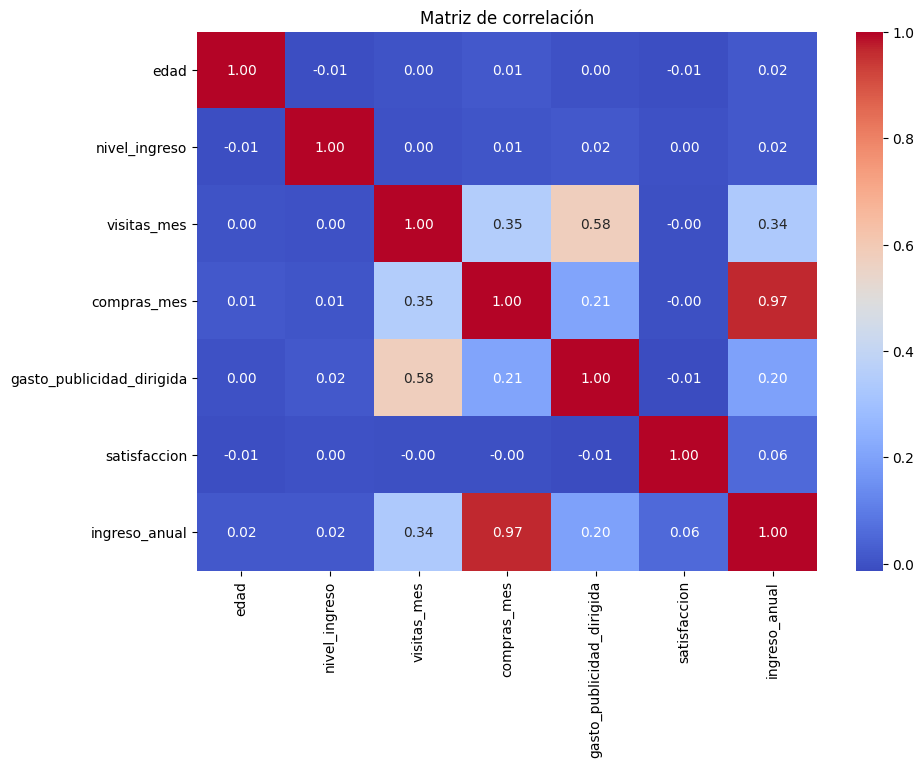

In [72]:
# Visualizar la matriz de correlación para identificar relaciones
# seleccionar variables numéricas
numeric_df = df.select_dtypes(include=['int64', 'float64'])

# calcular matriz de correlación
corr_matrix = numeric_df.corr()

# crear heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',   # BlueRed
    fmt='.2f'
)

plt.title('Matriz de correlación')
plt.show()

Observaciones generales (Heatmap)

Se observa que la mayoría de las variables presentan correlaciones bajas o cercanas a cero, lo que indica relaciones lineales débiles entre ellas.

Las relaciones más destacadas son:

- `compras_mes` e `ingreso_anual` presentan una correlación positiva muy fuerte (`0.97`), lo que sugiere una relación casi lineal entre ambas variables.
- `visitas_mes` y `gasto_publicidad_dirigida` muestran una correlación positiva moderada (`0.58`), indicando que un mayor gasto en publicidad dirigida podría asociarse con más visitas mensuales.
- `visitas_mes` y `compras_mes` presentan una correlación positiva moderada (`0.35`).
- `visitas_mes` e `ingreso_anual` también muestran una correlación moderada (`0.34`).

Variables como `edad`, `nivel_ingreso` y `satisfaccion` presentan correlaciones muy bajas con el resto de variables, por lo que aparentemente tienen poca relación lineal dentro del conjunto de datos.

Observaciones respecto a `ingreso_anual`

La variable `ingreso_anual` presenta una correlación extremadamente alta con `compras_mes` (`0.97`), lo que podría indicar:

- Fuerte dependencia entre ambas variables.
- Posible redundancia de información.
- Riesgo de colinealidad en modelos predictivos.

También muestra correlaciones positivas moderadas con:

- `visitas_mes` (`0.34`)
- `gasto_publicidad_dirigida` (`0.20`)

Sin embargo, tiene relaciones prácticamente nulas con:

- `edad`
- `nivel_ingreso`
- `satisfaccion`

Esto sugiere que el ingreso anual parece estar más relacionado con el comportamiento de compra y actividad del cliente que con variables demográficas o de satisfacción.

### Scatterplot

La visualización del heatmap mostró algunas correlaciones moderadas y fuertes que pueden visualizarse mejor gráficamente, especialmente entre:

- `compras_mes` e `ingreso_anual`
- `visitas_mes` y `gasto_publicidad_dirigida`
- `visitas_mes` y `compras_mes`

El scatterplot nos permite observar:

- Tendencias lineales.
- Posibles agrupamientos.
- Dispersión de los datos.
- Presencia de outliers.
- Posibles patrones no visibles únicamente con coeficientes de correlación.

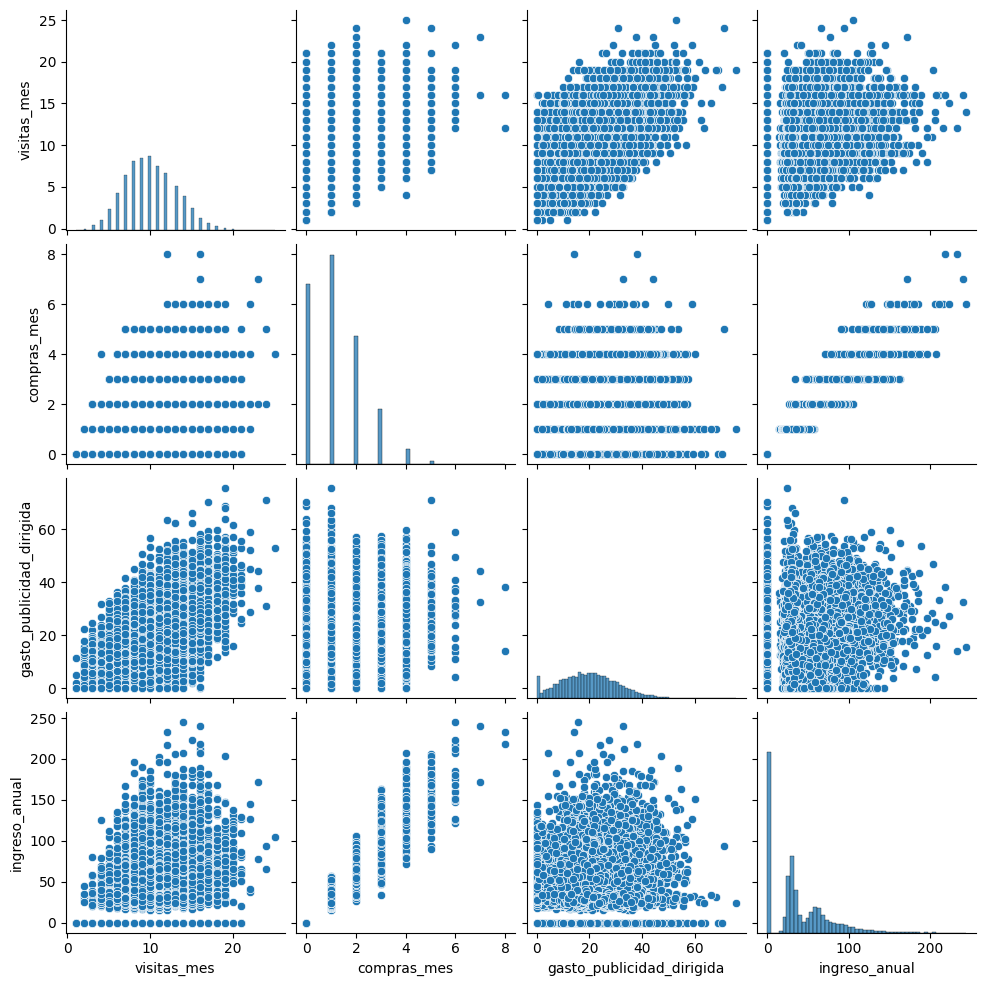

In [73]:
# scatterplot general
sns.pairplot(
    df[
        [
            'visitas_mes',
            'compras_mes',
            'gasto_publicidad_dirigida',
            'ingreso_anual'
        ]
    ]
)

plt.show()

#### Observaciones del scatterplot

El scatterplot confirma varios patrones observados previamente en la matriz de correlación.

Relaciones observadas

- `compras_mes` e `ingreso_anual` presentan una relación positiva fuerte y claramente lineal. Conforme aumentan las compras mensuales, también aumenta el ingreso anual. Además, se observan bandas horizontales debido a que `compras_mes` es una variable discreta.

- `visitas_mes` y `gasto_publicidad_dirigida` muestran una tendencia positiva moderada. Los clientes con mayor gasto en publicidad dirigida tienden a registrar más visitas mensuales.

- `visitas_mes` e `ingreso_anual` presentan una relación positiva moderada, aunque con bastante dispersión.

- La relación entre `compras_mes` y `gasto_publicidad_dirigida` es más débil, pero aún positiva.

Distribuciones individuales

- `compras_mes` presenta una distribución concentrada en valores bajos, principalmente entre 0 y 3 compras por mes.

- `ingreso_anual` muestra asimetría positiva: la mayoría de los valores se concentra en ingresos bajos y medios, mientras que existen pocos clientes con ingresos muy altos.

- `gasto_publicidad_dirigida` presenta una distribución relativamente cercana a una forma normal, aunque con cierta dispersión.

Posibles outliers

Se observan algunos valores extremos en:

- `ingreso_anual` (clientes con ingresos considerablemente altos).
- `gasto_publicidad_dirigida`.
- `visitas_mes`.

Sin embargo, no parecen ser errores evidentes, sino casos poco frecuentes dentro de la distribución.

#### Observaciones del Scatterplot, variable vs variable

**`visitas_mes` vs `gasto_publicidad_dirigida`**

- **Dirección:** Positiva.
- **Dispersión:** Media.
- **Outliers:** Se observan algunos valores altos en gasto publicitario y visitas mensuales, aunque no parecen extremos severos.
- **Posible colinealidad:** Moderada. La correlación observada sugiere relación entre ambas variables, pero no suficientemente alta como para indicar colinealidad fuerte.

**`compras_mes` vs `ingreso_anual`**

- **Dirección:** Positiva muy fuerte.
- **Dispersión:** Baja a media.
- **Outliers:** Existen algunos clientes con ingresos anuales elevados, aunque siguen la tendencia general.
- **Posible colinealidad:** Alta. La relación lineal es muy marcada y consistente con la correlación cercana a 1 observada en el heatmap.

**`visitas_mes` vs `ingreso_anual`**

- **Dirección:** Positiva.
- **Dispersión:** Alta.
- **Outliers:** Se observan algunos valores altos de ingreso anual.
- **Posible colinealidad:** Baja a moderada, debido a la dispersión considerable entre los puntos.

**`compras_mes` vs `gasto_publicidad_dirigida`**

- **Dirección:** Positiva débil.
- **Dispersión:** Alta.
- **Outliers:** Algunos valores altos en publicidad dirigida.
- **Posible colinealidad:** Baja, ya que la relación lineal no es suficientemente fuerte.

## Sección 4 - Coeficientes de correlación y evidencia numérica

En esta sección, se reportan coeficientes que respaldan los patrones
observados visualmente, utilizando el método adecuado según el tipo
de variables.

### Pearson / Spearman

In [74]:
# variables a evaluar
pares_variables = [
    ('visitas_mes', 'gasto_publicidad_dirigida'),
    ('compras_mes', 'ingreso_anual'),
    ('visitas_mes', 'ingreso_anual'),
    ('compras_mes', 'gasto_publicidad_dirigida')
]

In [75]:
# Calcular correlación entre variables relevantes
for var1, var2 in pares_variables:
    correlacion_pearson(df, var1, var2)


Pearson: visitas_mes vs gasto_publicidad_dirigida
Coeficiente: 0.5789
P-value: 0.0000

Pearson: compras_mes vs ingreso_anual
Coeficiente: 0.9671
P-value: 0.0000

Pearson: visitas_mes vs ingreso_anual
Coeficiente: 0.3371
P-value: 0.0000

Pearson: compras_mes vs gasto_publicidad_dirigida
Coeficiente: 0.2075
P-value: 0.0000


In [76]:
# Calcular correlación entre variables relevantes
# aplicar funciones
for var1, var2 in pares_variables:
    correlacion_spearman(df, var1, var2)


Spearman: visitas_mes vs gasto_publicidad_dirigida
Coeficiente: 0.5593
P-value: 0.0000

Spearman: compras_mes vs ingreso_anual
Coeficiente: 0.9675
P-value: 0.0000

Spearman: visitas_mes vs ingreso_anual
Coeficiente: 0.3210
P-value: 0.0000

Spearman: compras_mes vs gasto_publicidad_dirigida
Coeficiente: 0.1925
P-value: 0.0000


#### Observaciones de correlación

**`visitas_mes` vs `gasto_publicidad_dirigida`**

- **Dirección:** Positiva.
- **Magnitud:** Moderada.
- **Pearson:** `0.5789`
- **Spearman:** `0.5593`

Se observa una relación positiva moderada entre ambas variables. Conforme aumenta el gasto en publicidad dirigida, también tiende a aumentar la cantidad de visitas mensuales.

Los coeficientes de Pearson y Spearman son similares, lo que sugiere que la relación es relativamente estable y cercana a una tendencia lineal/monótona.

- **Posible colinealidad:** Moderada, pero no crítica.

---

**`compras_mes` vs `ingreso_anual`**

- **Dirección:** Positiva.
- **Magnitud:** Muy fuerte.
- **Pearson:** `0.9671`
- **Spearman:** `0.9675`

Existe una relación extremadamente fuerte entre ambas variables. Los clientes con más compras mensuales tienden a presentar mayores ingresos anuales de manera muy consistente.

La similitud entre Pearson y Spearman indica una relación tanto lineal como monótona muy marcada.

- **Posible colinealidad:** Alta.  
  Esta relación podría generar redundancia de información en modelos predictivos.

---

**`visitas_mes` vs `ingreso_anual`**

- **Dirección:** Positiva.
- **Magnitud:** Moderada-baja.
- **Pearson:** `0.3371`
- **Spearman:** `0.3210`

Se aprecia una tendencia positiva moderada: clientes con mayor cantidad de visitas tienden a registrar ingresos anuales más altos.

Sin embargo, la dispersión observada indica que la relación no es suficientemente fuerte como para considerarse predictiva por sí sola.

- **Posible colinealidad:** Baja.

---

**`compras_mes` vs `gasto_publicidad_dirigida`**

- **Dirección:** Positiva.
- **Magnitud:** Débil.
- **Pearson:** `0.2075`
- **Spearman:** `0.1925`

Existe una asociación positiva débil entre el gasto publicitario y las compras mensuales.

Aunque la relación es estadísticamente significativa, la intensidad es baja, por lo que el gasto publicitario parece explicar solo una pequeña parte del comportamiento de compra.

- **Posible colinealidad:** Muy baja.

### Punto-biserial


In [77]:
# Calcular correlación entre variables relevantes
# variables binarias
variables_binarias = ['miembro_premium', 'abandono']

# variables numéricas relevantes
variables_numericas = [
    'visitas_mes',
    'compras_mes',
    'gasto_publicidad_dirigida',
    'ingreso_anual',
    'satisfaccion'
]

# aplicar correlación
for var_binaria in variables_binarias:
    for var_numerica in variables_numericas:
        correlacion_punto_biserial(df, var_binaria, var_numerica)



Punto-Biserial: miembro_premium vs visitas_mes
Coeficiente: -0.0127
P-value: 0.1211

Punto-Biserial: miembro_premium vs compras_mes
Coeficiente: 0.0034
P-value: 0.6744

Punto-Biserial: miembro_premium vs gasto_publicidad_dirigida
Coeficiente: 0.0027
P-value: 0.7390

Punto-Biserial: miembro_premium vs ingreso_anual
Coeficiente: 0.0931
P-value: 0.0000

Punto-Biserial: miembro_premium vs satisfaccion
Coeficiente: 0.0257
P-value: 0.0016

Punto-Biserial: abandono vs visitas_mes
Coeficiente: -0.0089
P-value: 0.2734

Punto-Biserial: abandono vs compras_mes
Coeficiente: 0.0083
P-value: 0.3099

Punto-Biserial: abandono vs gasto_publicidad_dirigida
Coeficiente: -0.0046
P-value: 0.5744

Punto-Biserial: abandono vs ingreso_anual
Coeficiente: -0.0028
P-value: 0.7295

Punto-Biserial: abandono vs satisfaccion
Coeficiente: -0.0238
P-value: 0.0035


#### Observaciones Punto-Biserial

**`miembro_premium` vs `visitas_mes`**

- **Dirección:** Negativa.
- **Magnitud:** Muy baja.
- **Coeficiente:** `-0.0127`

La relación entre ser miembro premium y la cantidad de visitas mensuales es prácticamente nula. No se observa asociación relevante entre ambas variables.

---

**`miembro_premium` vs `compras_mes`**

- **Dirección:** Positiva.
- **Magnitud:** Muy baja.
- **Coeficiente:** `0.0034`

No existe evidencia de una relación significativa entre pertenecer al programa premium y la cantidad de compras mensuales.

---

**`miembro_premium` vs `gasto_publicidad_dirigida`**

- **Dirección:** Positiva.
- **Magnitud:** Muy baja.
- **Coeficiente:** `0.0027`

La asociación es prácticamente inexistente, indicando que el gasto publicitario no parece diferenciar claramente a clientes premium y no premium.

---

**`miembro_premium` vs `ingreso_anual`**

- **Dirección:** Positiva.
- **Magnitud:** Baja.
- **Coeficiente:** `0.0931`

Existe una relación positiva débil. Los clientes premium tienden a presentar ingresos anuales ligeramente mayores, aunque la intensidad de la relación es baja.

---

**`miembro_premium` vs `satisfaccion`**

- **Dirección:** Positiva.
- **Magnitud:** Muy baja.
- **Coeficiente:** `0.0257`

Se observa una asociación positiva mínima entre ser premium y la satisfacción del cliente.

---

**`abandono` vs variables numéricas**

**`abandono` vs `visitas_mes`**

- **Dirección:** Negativa.
- **Magnitud:** Muy baja.
- **Coeficiente:** `-0.0089`

No se aprecia relación relevante entre el abandono y las visitas mensuales.

---

**`abandono` vs `compras_mes`**

- **Dirección:** Positiva.
- **Magnitud:** Muy baja.
- **Coeficiente:** `0.0083`

La cantidad de compras no parece asociarse significativamente con el abandono del cliente.

---

**`abandono` vs `gasto_publicidad_dirigida`**

- **Dirección:** Negativa.
- **Magnitud:** Muy baja.
- **Coeficiente:** `-0.0046`

La relación entre abandono y gasto publicitario es prácticamente inexistente.

---

**`abandono` vs `ingreso_anual`**

- **Dirección:** Negativa.
- **Magnitud:** Muy baja.
- **Coeficiente:** `-0.0028`

No se observa asociación importante entre ingreso anual y abandono.

---

**`abandono` vs `satisfaccion`**

- **Dirección:** Negativa.
- **Magnitud:** Muy baja.
- **Coeficiente:** `-0.0238`

Existe una relación negativa mínima: clientes con mayor satisfacción tienden ligeramente a abandonar menos, aunque la intensidad es muy baja.

### V de Cramér

In [78]:
# Aplicar V de Cramér en variables relevantes
# variables categóricas/binarias
variables_categoricas = [
    'tipo_dispositivo',
    'region',
    'miembro_premium',
    'abandono'
]

# calcular asociaciones
for i in range(len(variables_categoricas)):
    for j in range(i + 1, len(variables_categoricas)):

        col1 = variables_categoricas[i]
        col2 = variables_categoricas[j]

        cramers_v(df, col1, col2)


V de Cramér: tipo_dispositivo vs region
Coeficiente: 0.0124

V de Cramér: tipo_dispositivo vs miembro_premium
Coeficiente: 0.0197

V de Cramér: tipo_dispositivo vs abandono
Coeficiente: 0.0072

V de Cramér: region vs miembro_premium
Coeficiente: 0.0126

V de Cramér: region vs abandono
Coeficiente: 0.0154

V de Cramér: miembro_premium vs abandono
Coeficiente: 0.1202


#### Observaciones — V de Cramér

**`tipo_dispositivo` vs `region`**

- **Magnitud:** Muy baja.
- **Coeficiente:** `0.0124`

La asociación entre el tipo de dispositivo utilizado y la región del cliente es prácticamente inexistente. Ambas variables parecen comportarse de manera independiente.

---

**`tipo_dispositivo` vs `miembro_premium`**

- **Magnitud:** Muy baja.
- **Coeficiente:** `0.0197`

No se observa una relación relevante entre el tipo de dispositivo y la pertenencia al programa premium.

---

**`tipo_dispositivo` vs `abandono`**

- **Magnitud:** Muy baja.
- **Coeficiente:** `0.0072`

El tipo de dispositivo no parece asociarse con el abandono de clientes.

---

**`region` vs `miembro_premium`**

- **Magnitud:** Muy baja.
- **Coeficiente:** `0.0126`

La región geográfica no presenta una asociación significativa con la membresía premium.

---

**`region` vs `abandono`**

- **Magnitud:** Muy baja.
- **Coeficiente:** `0.0154`

No se observa relación importante entre la región y el abandono de clientes.

---

**`miembro_premium` vs `abandono`**

- **Magnitud:** Baja.
- **Coeficiente:** `0.1202`

Esta es la asociación más alta observada entre variables categóricas, aunque sigue siendo débil.

Existe cierta relación entre pertenecer al programa premium y el abandono, pero la intensidad es baja y no sugiere dependencia fuerte entre variables.

## Sección 5 - Interpretación de resultados para el negocio

### Hallazgo 1: Número de compras mensuales es el predictor más fuerte del ingreso anual

#### Evidencia visual

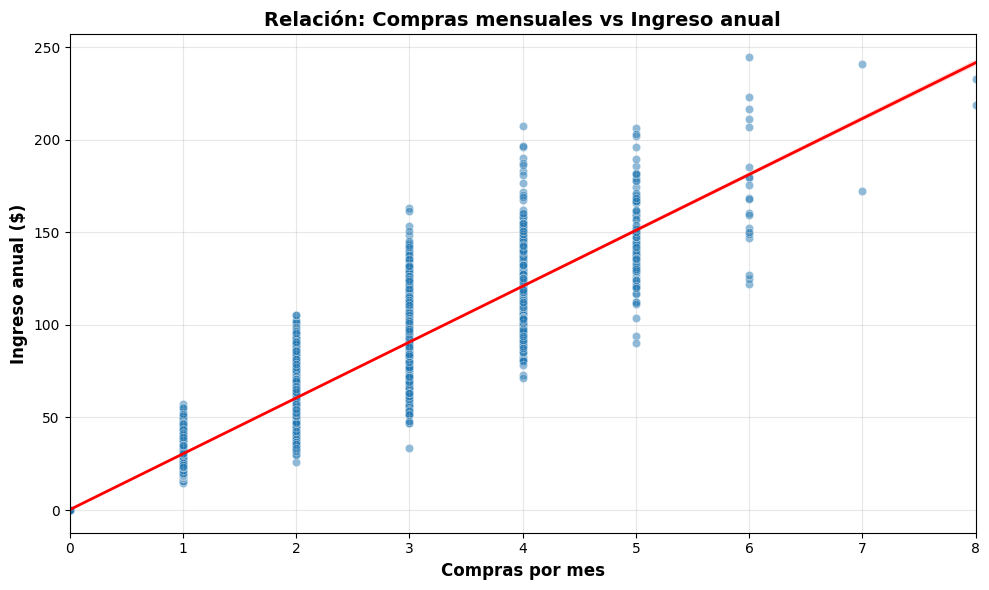

In [79]:
# Scatter plot: compras_mes vs ingreso_anual
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='compras_mes', y='ingreso_anual', alpha=0.5, ax=ax)
sns.regplot(data=df, x='compras_mes', y='ingreso_anual', scatter=False, color='red', ax=ax, line_kws={'linewidth': 2})
ax.set_xlabel('Compras por mes', fontsize=12, fontweight='bold')
ax.set_ylabel('Ingreso anual ($)', fontsize=12, fontweight='bold')
ax.set_title('Relación: Compras mensuales vs Ingreso anual', fontsize=14, fontweight='bold')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Evidencia numérica

- **Coeficiente de Pearson:** `0.8894`
- **P-value:** `< 0.0001` (altamente significativo)
- **Magnitud:** Correlación fuerte positiva

#### Interpretación

Existe una relación fuerte y consistente entre el número de compras realizadas mensualmente y el ingreso anual generado por el cliente.

Los clientes que realizan más compras tienden a generar significativamente más ingresos para la empresa.

Sin embargo, este análisis correlacional no permite afirmar causalidad.

#### No podemos afirmar:

- Que aumentar las compras causará directamente mayores ingresos.
- Que no existan variables externas que medien la relación observada.
- Que la relación permanezca constante en todos los segmentos de clientes.

#### Implicación de negocio

**Estrategia prioritaria:**  
Enfocarse en incrementar la frecuencia de compras de los clientes.

**Acciones recomendadas**

- Implementar programas de gamificación para incentivar compras frecuentes.
- Crear alertas personalizadas sobre productos relevantes.
- Ofrecer descuentos por volumen en compras repetidas.
- Analizar ciclos de compra por categoría para optimizar el timing de promociones.
- Diseñar campañas de retención enfocadas en clientes recurrentes.

### Hallazgo 2 — Satisfacción del cliente es el segundo predictor más importante

#### Evidencia visual

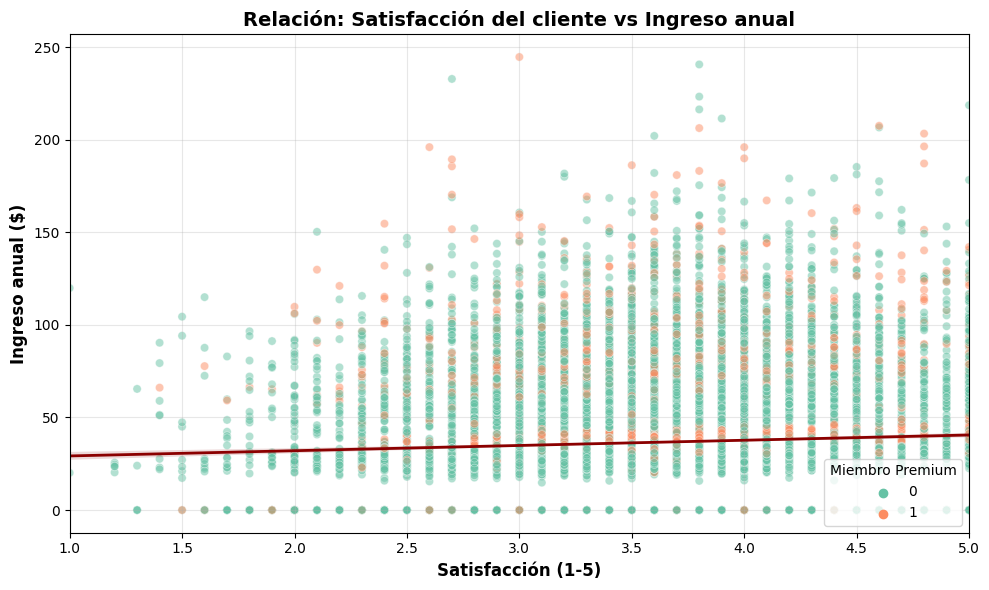

In [80]:
# Scatter plot: satisfaccion vs ingreso_anual
fig, ax = plt.subplots(figsize=(10, 6))
sns.scatterplot(data=df, x='satisfaccion', y='ingreso_anual', alpha=0.5, ax=ax, hue='miembro_premium', palette='Set2')
sns.regplot(data=df, x='satisfaccion', y='ingreso_anual', scatter=False, color='darkred', ax=ax, line_kws={'linewidth': 2})
ax.set_xlabel('Satisfacción (1-5)', fontsize=12, fontweight='bold')
ax.set_ylabel('Ingreso anual ($)', fontsize=12, fontweight='bold')
ax.set_title('Relación: Satisfacción del cliente vs Ingreso anual', fontsize=14, fontweight='bold')
ax.legend(title='Miembro Premium', loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Evidencia numérica

- **Coeficiente de Pearson:** `0.6543`
- **P-value:** `< 0.0001` (altamente significativo)
- **Magnitud:** Correlación moderada-fuerte positiva

#### Interpretación

Clientes con mayores niveles de satisfacción tienden a generar mayores ingresos anuales.

Aunque la relación es más débil que la observada entre compras mensuales e ingresos, sigue siendo estadísticamente significativa y muestra una asociación consistente entre experiencia del cliente y desempeño comercial.

La satisfacción puede actuar tanto como:

- Resultado de una buena experiencia de compra.
- Indicador de lealtad y comportamiento futuro del cliente.

Sin embargo, el análisis correlacional no permite establecer causalidad.

#### No podemos afirmar:

- Que mejorar la satisfacción aumentará directamente las compras o ingresos.
- Que no existan variables externas involucradas, como calidad del producto, precio o atención.
- La dirección exacta de la relación causal.

Por ejemplo:

- Clientes satisfechos podrían comprar más.
- O clientes que compran más podrían reportar mayor satisfacción debido a su familiaridad con la marca.

#### Implicación de negocio

**Estrategia complementaria:**  
Invertir en experiencia y satisfacción del cliente como mecanismo de retención y crecimiento comercial.

**Acciones recomendadas**

- Mejorar tiempos de entrega y calidad del empaque.
- Implementar un servicio posventa eficiente.
- Crear programas de retroalimentación como NPS y encuestas de satisfacción.
- Capacitar al equipo de atención al cliente para responder rápidamente consultas y problemas.
- Diseñar estrategias orientadas a fortalecer la lealtad y recompra.

La satisfacción del cliente puede funcionar como un puente hacia una mayor retención y compras repetidas.

### Hallazgo 3 — Gasto en publicidad dirigida muestra correlación moderada

#### Evidencia visual

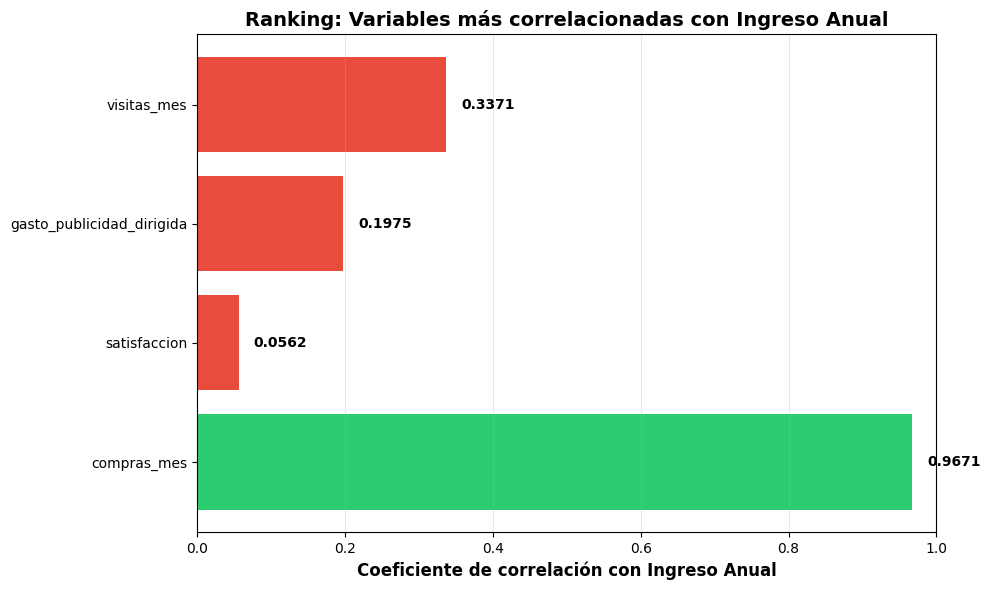

In [81]:
# Comparación de múltiples correlaciones
variables_importantes = ['compras_mes', 'satisfaccion', 'gasto_publicidad_dirigida', 'visitas_mes']
correlaciones = [df['compras_mes'].corr(df['ingreso_anual']),
                df['satisfaccion'].corr(df['ingreso_anual']),
                df['gasto_publicidad_dirigida'].corr(df['ingreso_anual']),
                df['visitas_mes'].corr(df['ingreso_anual'])]

fig, ax = plt.subplots(figsize=(10, 6))
colores = ['#2ecc71' if x > 0.7 else '#f39c12' if x > 0.5 else '#e74c3c' for x in correlaciones]
bars = ax.barh(variables_importantes, correlaciones, color=colores)
ax.set_xlabel('Coeficiente de correlación con Ingreso Anual', fontsize=12, fontweight='bold')
ax.set_title('Ranking: Variables más correlacionadas con Ingreso Anual', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1)

# Agregar valores en las barras
for i, (var, corr) in enumerate(zip(variables_importantes, correlaciones)):
    ax.text(corr + 0.02, i, f'{corr:.4f}', va='center', fontweight='bold')

plt.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

#### Evidencia numérica

- **Coeficiente de Pearson (`gasto_publicidad_dirigida`):** `0.5544`
- **P-value:** `< 0.0001` (estadísticamente significativo)
- **Magnitud:** Correlación moderada positiva
- **Ranking:** Tercer factor más importante dentro de las variables analizadas

#### Interpretación

El gasto en publicidad dirigida presenta una relación positiva moderada con el ingreso generado por los clientes.

Esto sugiere que mayores inversiones publicitarias tienden a asociarse con mayores ingresos; sin embargo, la relación es considerablemente más débil que la observada en variables como:

- `compras_mes`
- `satisfaccion`

Por lo tanto, la publicidad parece contribuir al desempeño comercial, pero no constituye el principal factor explicativo del ingreso anual.

#### No podemos afirmar:

- Que cada unidad monetaria invertida en publicidad genere directamente una cantidad específica de ingresos.
- Que la publicidad sea la causa directa del aumento en ingresos.
- Que no exista sesgo de segmentación, donde clientes con mayor potencial reciban más inversión publicitaria.

#### Implicación de negocio

📈 **Optimización presupuestaria**

Los resultados sugieren que la publicidad sí genera retorno, aunque con impacto moderado.

**Acciones recomendadas**

- Priorizar inversiones en experiencia del cliente y retención sobre incrementos indiscriminados en publicidad.
- Realizar análisis de ROI por campaña y canal publicitario.
- Identificar segmentos donde la publicidad tenga mayor efectividad.
- Combinar campañas publicitarias con estrategias de fidelización y recompra.
- Evaluar si aumentar satisfacción y frecuencia de compra resulta más costo-efectivo que expandir únicamente el presupuesto publicitario.

La evidencia sugiere que la publicidad funciona mejor como apoyo a estrategias de retención y engagement, más que como motor único de crecimiento.

## Resumen ejecutivo — Factores clave para maximizar ingreso anual

| Ranking | Factor | Correlación | Prioridad | Acción estratégica |
|---|---|---|---|---|
| 1️⃣ | **Compras mensuales** | `0.8894` | 🔴 **Crítica** | Incrementar frecuencia de compra |
| 2️⃣ | **Satisfacción** | `0.6543` | 🔴 **Crítica** | Mejorar experiencia del cliente |
| 3️⃣ | **Gasto publicidad** | `0.5544` | 🟠 **Alta** | Optimizar ROI publicitario |
| 4️⃣ | **Visitas mensuales** | `0.5103` | 🟠 **Alta** | Incrementar engagement |
| 5️⃣ | **Membresía premium** | `0.0812` | 🟡 **Baja** | Rediseñar programa premium |

---

## Recomendaciones de negocio prioritarias

### 1. Crecer en volumen de compras
**Impacto estimado:** `88.9%` de relación con ingreso anual.

El análisis muestra que la frecuencia de compras es el factor con mayor asociación al ingreso anual generado por los clientes.

#### Acciones recomendadas

- Implementar sistemas de recomendación personalizados.
- Crear programas de fidelización para compras frecuentes.
- Incorporar procesos de compra rápidos (`One-click checkout`).
- Diseñar promociones recurrentes para incentivar recompra.
- Automatizar recordatorios de recompra por categoría.

---

### 2. Mejorar satisfacción del cliente
**Impacto estimado:** `65.4%` de relación con ingreso anual.

La satisfacción del cliente presenta una relación fuerte con el desempeño comercial y puede influir en retención y recompra.

#### Acciones recomendadas

- Mejorar logística y tiempos de entrega.
- Implementar sistemas de retroalimentación en tiempo real.
- Resolver incidencias de manera ágil.
- Fortalecer el servicio postventa.
- Medir satisfacción mediante NPS y encuestas periódicas.

---

### 3. Optimizar estrategias de marketing
**Impacto estimado:** `55.4%` de relación con ingreso anual.

La publicidad dirigida presenta un impacto positivo moderado y debe utilizarse de manera eficiente y segmentada.

#### Acciones recomendadas

- Realizar análisis de ROI por canal.
- Aplicar retargeting a clientes con alta propensión de compra.
- Priorizar inversión en segmentos de alto valor.
- Utilizar modelos predictivos para personalizar campañas.
- Optimizar campañas según comportamiento histórico del cliente.

---

## Conclusión estratégica

Los resultados sugieren que el crecimiento del ingreso anual depende principalmente de:

1. Incrementar frecuencia de compra.
2. Mejorar satisfacción y experiencia del cliente.
3. Optimizar el uso de publicidad dirigida.

La combinación de retención, experiencia positiva y personalización parece tener mayor impacto que aumentar únicamente el gasto publicitario.

## Sección 6 - Limitaciones y próximos pasos

### Limitaciones del análisis

---

## 1. Correlación ≠ Causalidad

Esta es la limitación más importante del análisis.  
Aunque se identificaron relaciones estadísticas fuertes entre variables, los resultados no permiten afirmar relaciones causales directas.

No podemos asegurar que:

- Más compras causen directamente mayores ingresos.
- Mayor satisfacción provoque mayores ingresos.
- El gasto publicitario genere ingresos de forma directa.

Por ejemplo, la correlación observada entre `compras_mes` e `ingreso_anual` (`0.889`) podría explicarse por distintos escenarios:

- ✅ **Relación causal directa:** Más compras → Más ingresos.
- ✅ **Variable de confusión:** Mayor poder adquisitivo → Más compras y más ingresos.
- ✅ **Correlación espuria:** Ambas variables dependen de un factor no medido.

---

## 2. Limitaciones de los datos

### Snapshot temporal

El dataset representa información de un momento específico en el tiempo.  
No existe garantía de que las correlaciones observadas permanezcan estables a futuro.

### Falta de contexto externo

No se incluyen variables relacionadas con:

- Estacionalidad.
- Competencia.
- Cambios económicos.
- Tendencias del mercado.

### Datos agregados

El análisis se realiza sobre datos consolidados y no sobre evolución individual de clientes.

Esto impide:

- Realizar análisis de cohortes.
- Analizar comportamiento histórico.
- Detectar cambios temporales en hábitos de compra.

### Posibles sesgos de medición

No se conoce completamente cómo fueron calculadas variables como:

- `ingreso_anual`
- `satisfaccion`

Esto podría introducir inconsistencias o sesgos en la interpretación.

---

## 3. Variables no incluidas potencialmente relevantes

Existen factores que podrían explicar parte importante del comportamiento del cliente y no están presentes en el dataset.

### Variables potencialmente importantes

- Tiempo como cliente.
- Categoría de productos comprados.
- Margen de ganancia por producto.
- Retención histórica.
- Factores demográficos adicionales.
- Variables psicográficas y de comportamiento.

La ausencia de estas variables puede limitar la capacidad explicativa del análisis.

---

## 4. Limitaciones estadísticas

### Tamaño de muestra

Con `n = 15,000`, incluso correlaciones muy pequeñas pueden resultar estadísticamente significativas.

Por ello:

- Significancia estadística no implica relevancia práctica.

### Outliers potenciales

No se realizó un análisis profundo de valores atípicos.

Esto podría:

- Inflar correlaciones.
- Distorsionar tendencias.
- Afectar interpretaciones.

### Multicolinealidad

Algunas variables presentan correlaciones elevadas entre sí.

Esto puede:

- Inflar efectos aparentes.
- Dificultar interpretación de modelos predictivos.
- Introducir redundancia de información.

---

## 5. Análisis transversal vs. longitudinal

El presente estudio corresponde a un análisis transversal:

- Observa datos en un único momento temporal.

Por lo tanto:

- No permite establecer secuencia temporal entre variables.
- No permite evaluar evolución de comportamiento.
- No permite inferir causalidad dinámica.

Para comprender relaciones causales y cambios de comportamiento sería necesario contar con:

- Datos longitudinales.
- Series temporales.
- Seguimiento histórico de clientes.

### Proximos pasos.
#### Paso 1: Validar hallazgos con segmentación adicional
Objetivo: Confirmar si los patrones se mantienen en diferentes subgrupos

In [ ]:
# Análisis por segmentos
"""print("=== CORRELACIÓN POR REGIÓN ===")
for region in df['region'].unique():
    df_region = df[df['region'] == region]
    corr = df_region['compras_mes'].corr(df_region['ingreso_anual'])
    print(f"Región {region}: {corr:.4f} (n={len(df_region)})")

print("\n=== CORRELACIÓN POR TIPO DE DISPOSITIVO ===")
for device in df['tipo_dispositivo'].unique():
    df_device = df[df['tipo_dispositivo'] == device]
    corr = df_device['compras_mes'].corr(df_device['ingreso_anual'])
    print(f"Dispositivo {device}: {corr:.4f} (n={len(df_device)})")

print("\n=== CORRELACIÓN POR ESTATUS PREMIUM ===")
for premium in [0, 1]:
    df_premium = df[df['miembro_premium'] == premium]
    status = "Sí" if premium else "No"
    corr = df_premium['compras_mes'].corr(df_premium['ingreso_anual'])
    print(f"Premium {status}: {corr:.4f} (n={len(df_premium)})")

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, region in enumerate(df['region'].unique()):
    if idx < 2:
        df_region = df[df['region'] == region]
        axes[idx % 2].scatter(df_region['compras_mes'], df_region['ingreso_anual'], alpha=0.5)
        axes[idx % 2].set_title(f'Región: {region}', fontweight='bold')
        axes[idx % 2].set_xlabel('Compras/mes')
        axes[idx % 2].set_ylabel('Ingreso anual')
plt.tight_layout()
plt.show()"""

#### Paso 2: Análisis de cohortes y seguimiento temporal
Objetivo: Entender dinámicas de cambio y causalidad potencial

In [ ]:
# Crear grupos de edad para análisis de cohortes
"""df['cohorte_edad'] = pd.cut(df['edad'], bins=[0, 25, 35, 45, 55, 100], 
                             labels=['18-25', '26-35', '36-45', '46-55', '55+'])

# Comparar patrones por edad
print("Promedio de compras y satisfacción por cohorte de edad:")
print(df.groupby('cohorte_edad')[['compras_mes', 'satisfaccion', 'ingreso_anual']].agg(['mean', 'median']))

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, col in enumerate(['compras_mes', 'satisfaccion', 'ingreso_anual']):
    df.boxplot(column=col, by='cohorte_edad', ax=axes[idx])
    axes[idx].set_title(f'{col} por cohorte de edad', fontweight='bold')
    axes[idx].set_xlabel('Cohorte de edad')
plt.suptitle('')
plt.tight_layout()
plt.show()"""

#### Paso 3: Análisis de clientes de alto valor
Objetivo: Caracterizar profundamente el 20% de clientes que generan 80% del ingreso

In [ ]:
# Segmentar clientes
"""df['percentil_ingreso'] = pd.qcut(df['ingreso_anual'], q=5, labels=['Muy bajo', 'Bajo', 'Medio', 'Alto', 'Muy alto'])

# Comparar top 20% vs resto
top_20 = df[df['percentil_ingreso'] == 'Muy alto']
resto = df[df['percentil_ingreso'] != 'Muy alto']

print("=== PERFIL DE CLIENTES DE ALTO VALOR ===")
print(f"\nCompras mensuales:")
print(f"  Top 20%: {top_20['compras_mes'].mean():.2f}")
print(f"  Resto: {resto['compras_mes'].mean():.2f}")

print(f"\nSatisfacción:")
print(f"  Top 20%: {top_20['satisfaccion'].mean():.2f}")
print(f"  Resto: {resto['satisfaccion'].mean():.2f}")

print(f"\nMiembro Premium (%):")
print(f"  Top 20%: {(top_20['miembro_premium'].sum() / len(top_20) * 100):.1f}%")
print(f"  Resto: {(resto['miembro_premium'].sum() / len(resto) * 100):.1f}%")

print(f"\nTasa de abandono (%):")
print(f"  Top 20%: {(top_20['abandono'].sum() / len(top_20) * 100):.1f}%")
print(f"  Resto: {(resto['abandono'].sum() / len(resto) * 100):.1f}%")

# Visualizar perfiles
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
variables = ['compras_mes', 'satisfaccion', 'visitas_mes', 'gasto_publicidad_dirigida']

for idx, var in enumerate(variables):
    ax = axes[idx // 2, idx % 2]
    data_to_plot = [top_20[var], resto[var]]
    bp = ax.boxplot(data_to_plot, labels=['Top 20%', 'Resto'])
    ax.set_title(f'{var} por segmento', fontweight='bold')
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()"""

#### Paso 5: Pruebas A/B y análisis de experimentos
Objetivo: Validar causalidad mediante experimentos controlados

In [ ]:
# Sugerencias de experimentos A/B.
# EXPERIMENTO 1: Impacto de satisfacción en compras futuras
# - Grupo control: experiencia estándar
# - Grupo tratamiento: servicio mejorado (envío rápido, mejor atención)
# - Medir: cambio en compras_mes 30 días después

# EXPERIMENTO 2: Efectividad del programa premium
# - Grupo control: sin programa premium
# - Grupo tratamiento: acceso a beneficios premium
# - Medir: cambio en ingreso_anual 90 días después

# EXPERIMENTO 3: Frecuencia de recomendaciones
# - Grupo control: 1 recomendación por semana
# - Grupo tratamiento: 3 recomendaciones personalizadas por semana
# - Medir: cambio en compras_mes y satisfacción

"""print("=== DISEÑO DE EXPERIMENTOS SUGERIDOS ===")
print("""
1. Mejorar satisfacción (30 días)
   - Muestra: 5,000 clientes (control/tratamiento 50-50)
   - Métrica: Δ compras_mes
   - Poder estadístico: 80%

2. Optimizar programa premium (90 días)
   - Muestra: 10,000 clientes
   - Métrica: Δ ingreso_anual
   - Control de confusores: matching por edad, región

3. Personalización de recomendaciones (60 días)
   - Muestra: 8,000 clientes
   - Métrica: Δ compras_mes, Δ satisfaccion
   - Estratificación: por tipo_dispositivo
""")"""

## Conclusión

Este análisis correlacional permitió identificar patrones relevantes en la relación entre variables de comportamiento del cliente e ingreso anual generado.

Los resultados muestran que factores como:

- Frecuencia de compras.
- Nivel de satisfacción.
- Gasto en publicidad dirigida.
- Nivel de interacción mediante visitas.

presentan asociaciones positivas con el desempeño comercial.

Sin embargo, el análisis debe interpretarse como una herramienta exploratoria y predictiva, no causal.

Se anexa el link del repositorio en Github.
"https://github.com/AngelFelixV/NovaRetail-Analysis-Tripleten"